# DFT-1/2   
**by <span style="color:darkgreen">Ronaldo Rodrigues Pela</span> & <span style="color:darkgreen">Dmitrii Nabok</span> for [<span style="color:darkgoldenrod">exciting *magnesium*</span>](https://www.exciting-code.org/magnesium)**

<font size="2">(Jupyter notebook by <span style="color:darkgreen">Mara Voiculescu</span> & <span style="color:darkgreen">Martin Kuban</span>)</font>
<hr style="border:2px solid #DDD"> </hr>

**<span style="color:firebrick">Purpose</span>**: In this tutorial, you will learn how to run **DFT-1/2** calculations using **`exciting`**. An explicit example is given for **Si** and **GaN**.
<hr style="border:2px solid #DDD"> </hr>

<div class="alert alert-block alert-warning">

**Table of Contents**
    
[0. Before Starting](#0)
    
[1. Introduction](#1)  
    
[2. Running a Simple LDA-1/2 Calculation](#2)

[3. Optimizing the Choice of the Parameter "cut"](#3)  
   - [Bulk Si](#3)
   - [Bulk GaN](#3.2)
   - [Band structure and DOS](#3.3)
   - [Transferability](#3.3) 

[Literature](#4)
</div>

<a id='0'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">0. Before Starting</span>

**<span style="color:firebrick">Read the following paragraphs before starting with the rest of this tutorial!</span>**

Before running any Jupyter tutorials, please refer to the **`00_before_starting.md`** document on how to correctly set up the environment. This only needs to be done once. After which, the **venv** can be (re)activated from **`exciting`**'s root directory:

<div style="background-color: rgb(224, 224, 224);">

```bash
source $EXCITINGROOT/tools/excitingjupyter/venv/excitingvenv/bin/activate
```

</div>

As a first step, you may create a running directory for the notebook.

In [ ]:
%%bash -l
mkdir -p run_tutorial_LDA_0.5

<a id='1'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">1. Introduction</span>
The **DFT-1/2** method, in principle, is suitable only for correcting the Kohn-Sham (**KS**) eigenvalues around the bottom of conduction band and the top of valence band. This means that the method is appropriate for calculating single-particle band gaps, but not for calculating properties that depend, *e.g*., on the total energy. For compounds with not too large band gaps (typically not larger than ~ 10 eV), it can reach good accuracy with the same computational cost of the standard (semi)local functionals. Within this approach, the **KS** potential $V_{\text{KS}}(\textbf{r})$ of a standard DFT calculation is replaced by a modified **KS** potential $V_{\text{mod-KS}}(\textbf{r}) = V_{\text{KS}}(\textbf{r}) - V_{\text{S}}(\textbf{r})$. The "*correction*" $V_{\text{S}}(\textbf{r})$, named as self-energy potential (because of its similarity to a classical electrostatic self-energy), is calculated for the atoms which form the crystal, and is transferred to the crystal after a trimming process defined by the function:

$$\Theta (r) = \left\{ \begin{array}{ll} A\left[1-\left(\frac{r}{r_{\rm cut}} \right)^{\!\!n} \right]^3 & r \le r_{\rm cut} \\ 0 & r>r_{\rm cut} \end{array} \right.$$

The $r_{\text{cut}}$ is to be determined variationally (see **Section 3**), $n$ is usually taken as **8**, and $A$, the amplitude of the correction, is equal to **1**. Note that setting $r_{\text{cut}}=0$ corresponds to a standard **DFT** calculation. Depending on the exchange and correlation employed, one can have, *e.g*., **LDA-1/2** or **GGA-1/2**. Here, we will employ **LDA-1/2**. The suffix "**-1/2**" comes from the fact that the corrective potential mimics the **half-occupation** scheme of Slater. The self-energy potential is defined for each atom that comprises the crystal as a difference of the **KS** potential for the neutral atom and the **KS** potential for the half-ionized one (here, the shell to be ionized is that one that gives rise to the valence band).

<a id='2'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">2. Running a Simple LDA-1/2 Calculation</span>
Start by creating a working directory for the first calculation

In [ ]:
%%bash -l
cd run_tutorial_LDA_0.5
mkdir -p LDA_0.5_test_01
cd ..

Here is one input file (**input.xml**) for bulk Si.

<span class="SILICON_LDA_1/2"></span>
```xml
<input>
 
   <title>Bulk Silicon: LDA-1/2 example</title>
 
   <structure speciespath="$EXCITINGROOT/species">
      <crystal scale="10.26">
         <basevect>0.0   0.5   0.5</basevect>
         <basevect>0.5   0.0   0.5</basevect>
         <basevect>0.5   0.5   0.0</basevect>
      </crystal>
      <species speciesfile="Si.xml" rmt="2.1">
         <atom coord="0.00  0.00  0.00"></atom>
         <atom coord="0.25  0.25  0.25"></atom>
         <dfthalfparam>
            <shell cut="3.90" ampl="1" exponent="8" number="0" ionization="0.25" />
         </dfthalfparam>
      </species>
   </structure>
 
   <groundstate
      do="fromscratch"
      rgkmax="7.0"
      gmaxvr="14"
      ngridk="6 6 6"
      outputlevel="high"
      xctype="LDA_PW">
      <dfthalf printVSfile="false"/>
   </groundstate>
 
</input>
```

In [ ]:
from excitingjupyter.utilities import get_input_xml_from_notebook   

# Extract input file content from this notebook:
input_str = get_input_xml_from_notebook("dft_0.5", "SILICON_LDA_1/2")

# Write out the input as an XML file:
with open('./run_tutorial_LDA_0.5/LDA_0.5_test_01/input.xml', "w") as fid:
    fid.write(input_str)

Let us take a closer look at this input file. Please note that in production calculations one should always check the appropriate value of the <code><span style="color:mediumblue">cut</span></code> attribute as well as the values of the other attributes of the <code><span style="color:green">shell</span></code> element which identify the shell that should be ionized, namely <code><span style="color:mediumblue">number</span></code> and <code><span style="color:mediumblue">ionization</span></code>. The element <code><span style="color:green">dfthalf</span></code> triggers the **DFT-1/2** calculation: Without it, a standard DFT calculation is performed. The description of the attributes and elements concerning the **DFT-1/2** are given in the table below:

Parameter|Description
:-----------|:--------------------------------
<code><span style="color:green">shell</span>/<span style="color:mediumblue">cut</span></code>|Specifies the value of $r_{\text{cut}}$ (in Bohr) for the self-energy potential, which determines the range of the correction. Note that this can/should be specified for each species.
<code><span style="color:green">shell</span>/<span style="color:mediumblue">ampl</span></code>|Specifies the amplitude of the self-energy potential.
<code><span style="color:green">shell</span>/<span style="color:mediumblue">exponent</span></code>|The exponent $n$ that appears in the function that trims the correction.
<code><span style="color:green">shell</span>/<span style="color:mediumblue">number</span></code>, <code><span style="color:green">shell</span>/<span style="color:mediumblue">ionization</span></code> |The value of these attributes determines the number of the shell that is to be ionized and the ionization that must be applied to this shell. The attribute <code><span style="color:mediumblue">number</span></code> follows the same convention used in the species file, where <code><span style="color:firebrick">"0"</span></code> is the shortcut that defines the last atomic shell. According to the convention, the *1s* shell is always identified by <code><span style="color:mediumblue">number</span>=<span style="color:firebrick">"1"</span></code> (in our example for Si, a number equal to <code><span style="color:firebrick">"7"</span></code> would have the same result as <code><span style="color:firebrick">"0"</span></code>). The attribute <code><span style="color:mediumblue">ionization</span></code> specifies the amount of charge that is to be removed from this shell when generating the corresponding $V_{\text{S}}(\textbf{r})$ potential.
<code><span style="color:green">dfthalf</span>/<span style="color:mediumblue">printVSfile</span></code>|Optional attribute. When set to <code><span style="color:firebrick">"true"</span></code>, the self-energy correction potential $V_{\text{S}}(\textbf{r})$ (as defined in the **DFT-1/2** method) is calculated for each constituent atomic species and written into the files **VS_S*.OUT**, where <b>*</b> ranges from **1** to the number of atomic species. The **`exciting`** run quits after the printing. In this case, a serial calculation is suggested. It is useful to visualize the self-energy potential, or for debugging purposes.

You can see that for Si, because there are two identical atoms in the unit cell, we need to remove 1/4 electron of the last shell in order to have the ionization scheme of 1/2 in the valence band. The shell that is being ionized is the one that corresponds to 3p orbital, which will further form the top of the valence band in the bulk. When performing **DFT-1/2** calculations, we always suggest to use
```xml
<groundstate
      ...
      outputlevel="high"
      ...>
      ...
</groundstate>
```
within the <code><span style="color:green">groundstate</span></code> element: This will print in the output **INFO.OUT** the contribution of the $V_{\text{S}}(\textbf{r})$ potential to the total energy (basically, the integral of this potential times the electronic density evaluated in the entire unit cell).

To perform the actual calculation, make sure to set **$EXCITINGROOT** to the correct **`exciting`** root directory in the <code><span style="color:mediumblue">speciespath</span></code> attribute using the command

In [ ]:
%%bash -l
cd run_tutorial_LDA_0.5/LDA_0.5_test_01
python3 -m excitingscripts.setup.excitingroot
cd ../..

Now you can start the calculation by executing the following script

In [ ]:
%%bash -l
cd run_tutorial_LDA_0.5
python3 -m excitingscripts.execute.single -r LDA_0.5_test_01
cd ..

The output files of this run are stored inside the directory **lda05-test-01**. After running this calculation, one can inspect the **INFO.OUT** and look for the band gap. In this case, it is obtained a gap of about **0.0435** Ha, or **1.18** eV, which is quite close to the experimental band gap of Si (**1.17** eV).

<a id='3'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">Optimizing the Choice of the Parameter "cut"</span>
#### <span style="color:#15317E">3.1 Bulk Si</span>
The parameter $r_{\text{cut}}$, which defines the range of the corrective potential within the **DFT-1/2** method, is specified by the value of the attribute <code><span style="color:mediumblue">cut</span></code>. The "right" value of $r_{\text{cut}}$, to be used in production calculations, must be determined variationally, by making the band gap extreme. This is achieved in the example of Si using the following procedure. First, $r_{\text{cut}}$ is varied between **0** and **5** Bohr (a step of **0.5** Bohr is a good choice, but should be refined). Then, run the calculations and search for the one that gives a maximum to the band gap of Si. You can do this manually, but it would be a tedious task. We will provide a script that takes care of this job. Now, go back to the **run_tutorial_LDA_0.5** directory and create a subdirectory (**cut-Si**) to perform this kind of calculation and copy the input file **input.xml** inside it.. 

In [ ]:
%%bash -l
cd run_tutorial_LDA_0.5
mkdir -p cut-Si
cp LDA_0.5_test_01/input.xml cut-Si
cd ..

First, create another subdirectory **coarse** in which you will perform the calculations.

In [ ]:
%%bash -l
cd run_tutorial_LDA_0.5/cut-Si
mkdir -p coarse

To execute the series of calculations varying the $r_{\text{cut}}$, you need first to run the script **`excitingscripts.setup.dft_05`** as follows.

In [ ]:
%%bash -l
cd run_tutorial_LDA_0.5/cut-Si
python3 -m excitingscripts.setup.dft_05 0 5 11 -s Si -r coarse
cd ../..

The first argument (here **0** in the example) determines the minimum value of $r_{\text{cut}}$ in the series of calculations. The second entry (**5.0**) is, on the other hand, the maximum value of $r_{\text{cut}}$. The third entry (**11**) determines the number of steps to be considered between the minimum and maximum values of $r_{\text{cut}}$ (here the number **11** provides a step of **0.5**, as we recommended before). The next entry (**Si**) specifies the species with respect to which we vary $r_{\text{cut}}$. Finally, the working directory **coarse**, containing input files for different values of $r_{\text{cut}}$ is specified.

To execute the series of calculations with input files created by **`excitingscripts.setup.dft_05`**, you have to run the script **`excitingscripts.execute.elastic_strain`**. As a final remark, it is worth mentioning that, despite its name, the script **`excitingscripts.execute.elastic_strain`**, in DFT-1/2 calculations, is not supposed to execute strain calculations, as done in the tutorial **Energy vs. Strain Calculations** - here the same script is reused with a different purpose. The execution of DFT-1/2 calculations is specified by the presence of the argument **dft-05**.

In [ ]:
%%bash -l 
cd run_tutorial_LDA_0.5/cut-Si/coarse
python3 -m excitingscripts.execute.elastic_strain --dft-half
cd ../../..

This set of calculations should last a few minutes (typically 1 or 2). Inside this directory, results of the calculation for the input file **input-i.xml** are contained in the subdirectory **rundir-i** where **i** is running from **1** to the total number of steps (in our case, **11**). During the calculation, results for the value of the band gap (in eV) as a function of the $r_{\text{cut}}$ parameter (in Bohr) are stored in the file **bandgap-vs-rcut**. The content of this file should look like this

```
     0.00000000    0.6059858708
     0.50000000    0.6191368617
     1.00000000    0.6226174701
     1.50000000    0.6392923355
     2.00000000    0.7316698216
     2.50000000    0.9076733399
     3.00000000    1.1026573444
     3.50000000    1.1982754346
     4.00000000    1.1691102708
     4.50000000    1.0394795805
     5.00000000    0.8522698691
```

In order to visualize the results, you can execute the script **`excitingscripts.plot.files`** as follows.

In [ ]:
%%bash -l
cd run_tutorial_LDA_0.5/cut-Si/coarse
python3 -m excitingscripts.plot.files -f bandgap-vs-rcut -lx '$r_{cut}$ [Bohr]' -ly 'Bandgap [eV]' -g -pm
cd ../../..

In the example presented here, you should get something similar to the following plot.

<figure>
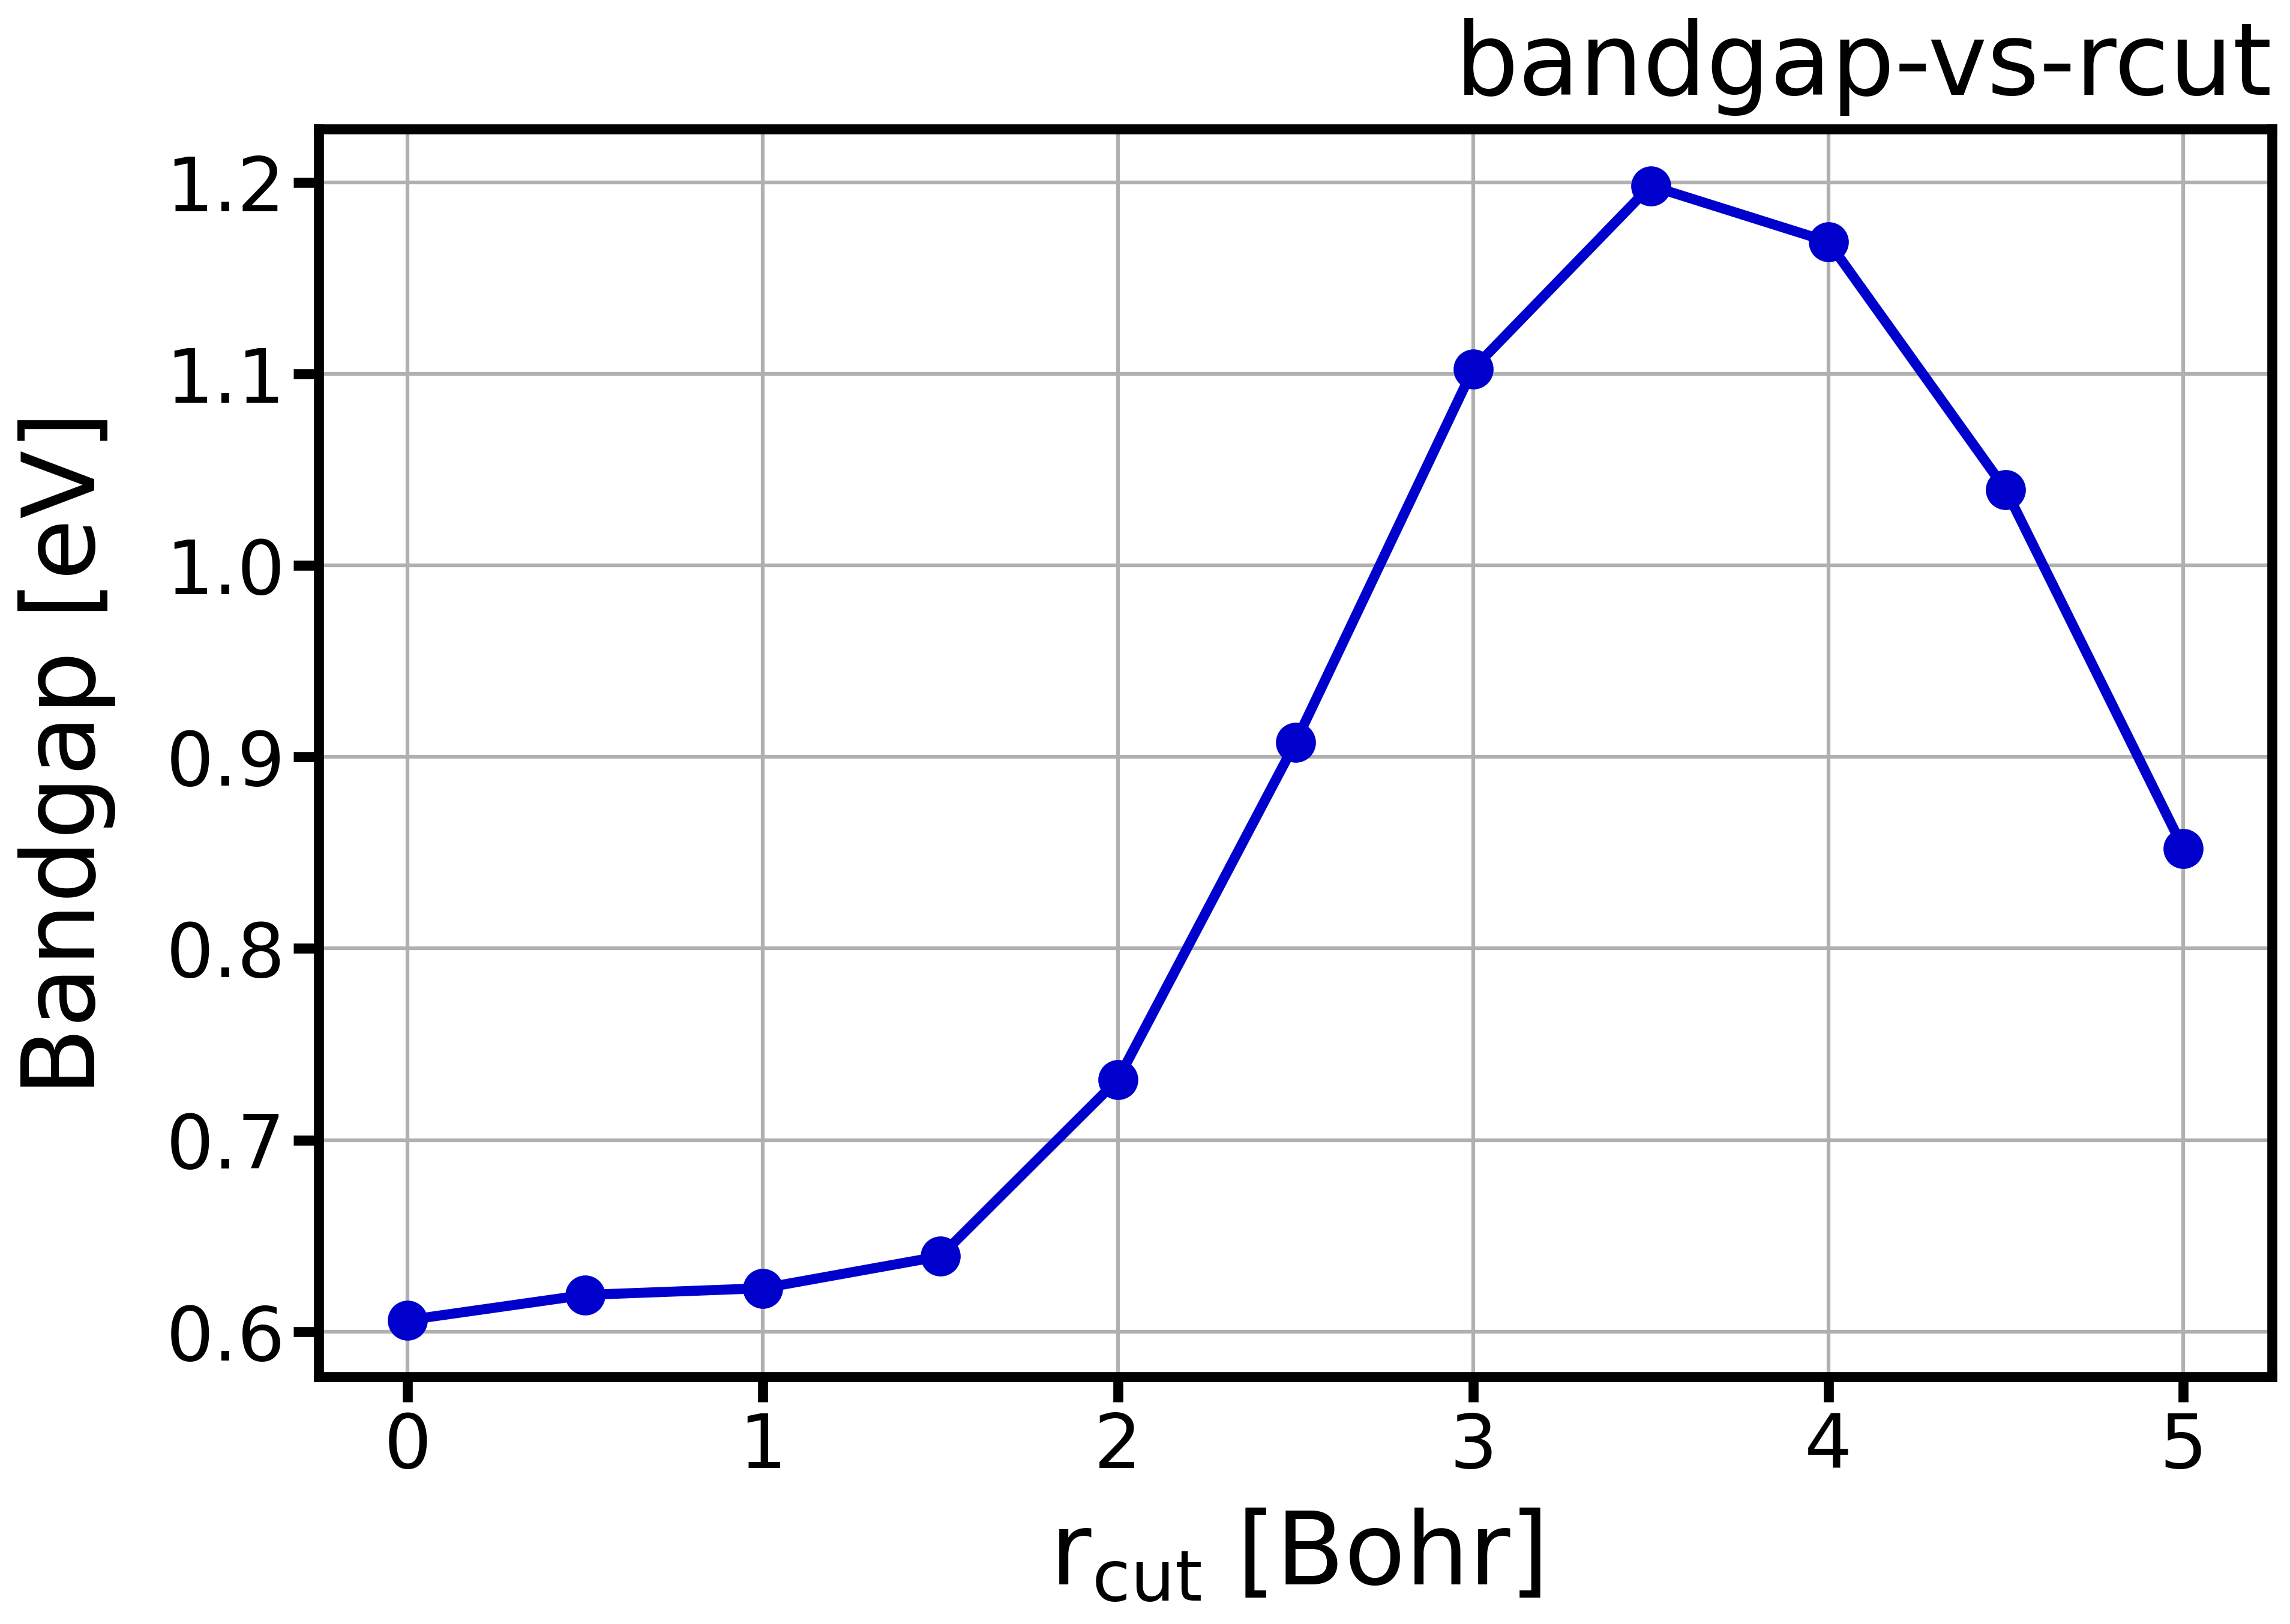
</figure>

Now, you can refine the search for the $r_{\text{cut}}$ that maximizes the band gap. Go back to the previous directory, create a new subdirectory **fine** and setup a new refined calculation as follows.

In [ ]:
%%bash -l
cd run_tutorial_LDA_0.5/cut-Si
mkdir -p fine
python3 -m excitingscripts.setup.dft_05 3.6 3.9 4 -s Si -r fine
cd ../..

After this, you can run this new set of calculations by entering

In [ ]:
%%bash -l 
cd run_tutorial_LDA_0.5/cut-Si/fine
python3 -m excitingscripts.execute.elastic_strain --dft-half
cd ../../..

If you look at the content of the file **fine/bandgap-vs-rcut**, you will obtain the following result.
```
     3.60000000    1.2020510144
     3.70000000    1.2008270463
     3.80000000    1.1947749618
     3.90000000    1.1841189830
```

In order to comprise all the results that you have so far, you can concatenate the file **bandgap-vs-rcut** inside the directory **fine**, with that one inside **coarse**. You can easily do this using the following command.

In [ ]:
%%bash -l 
cd run_tutorial_LDA_0.5/cut-Si
cat coarse/bandgap-vs-rcut fine/bandgap-vs-rcut | sort > ./bandgap-with-all
cd ../..

The file **bandgap-with-all**, located in the current directory, will have all the data from the previous two series of calculations, sorted by the value of $r_{\text{cut}}$. Its content is:
```
     0.00000000    0.6059858708
     0.50000000    0.6191368617
     1.00000000    0.6226174701
     1.50000000    0.6392923355
     2.00000000    0.7316698216
     2.50000000    0.9076733399
     3.00000000    1.1026573444
     3.50000000    1.1982754346
     3.60000000    1.2020510144
     3.70000000    1.2008270463
     3.80000000    1.1947749618
     3.90000000    1.1841189830
     4.00000000    1.1691102708
     4.50000000    1.0394795805
     5.00000000    0.8522698691
```

You can now visualize this new file using the following command.

In [ ]:
%%bash -l
cd run_tutorial_LDA_0.5/cut-Si
python3 -m excitingscripts.plot.files -f bandgap-with-all  -lx '$r_{cut}$ [Bohr]'  -ly 'Bandgap [eV]'  -g  -pm
cd ../..

The corresponding plot should appear like the following.

<figure>
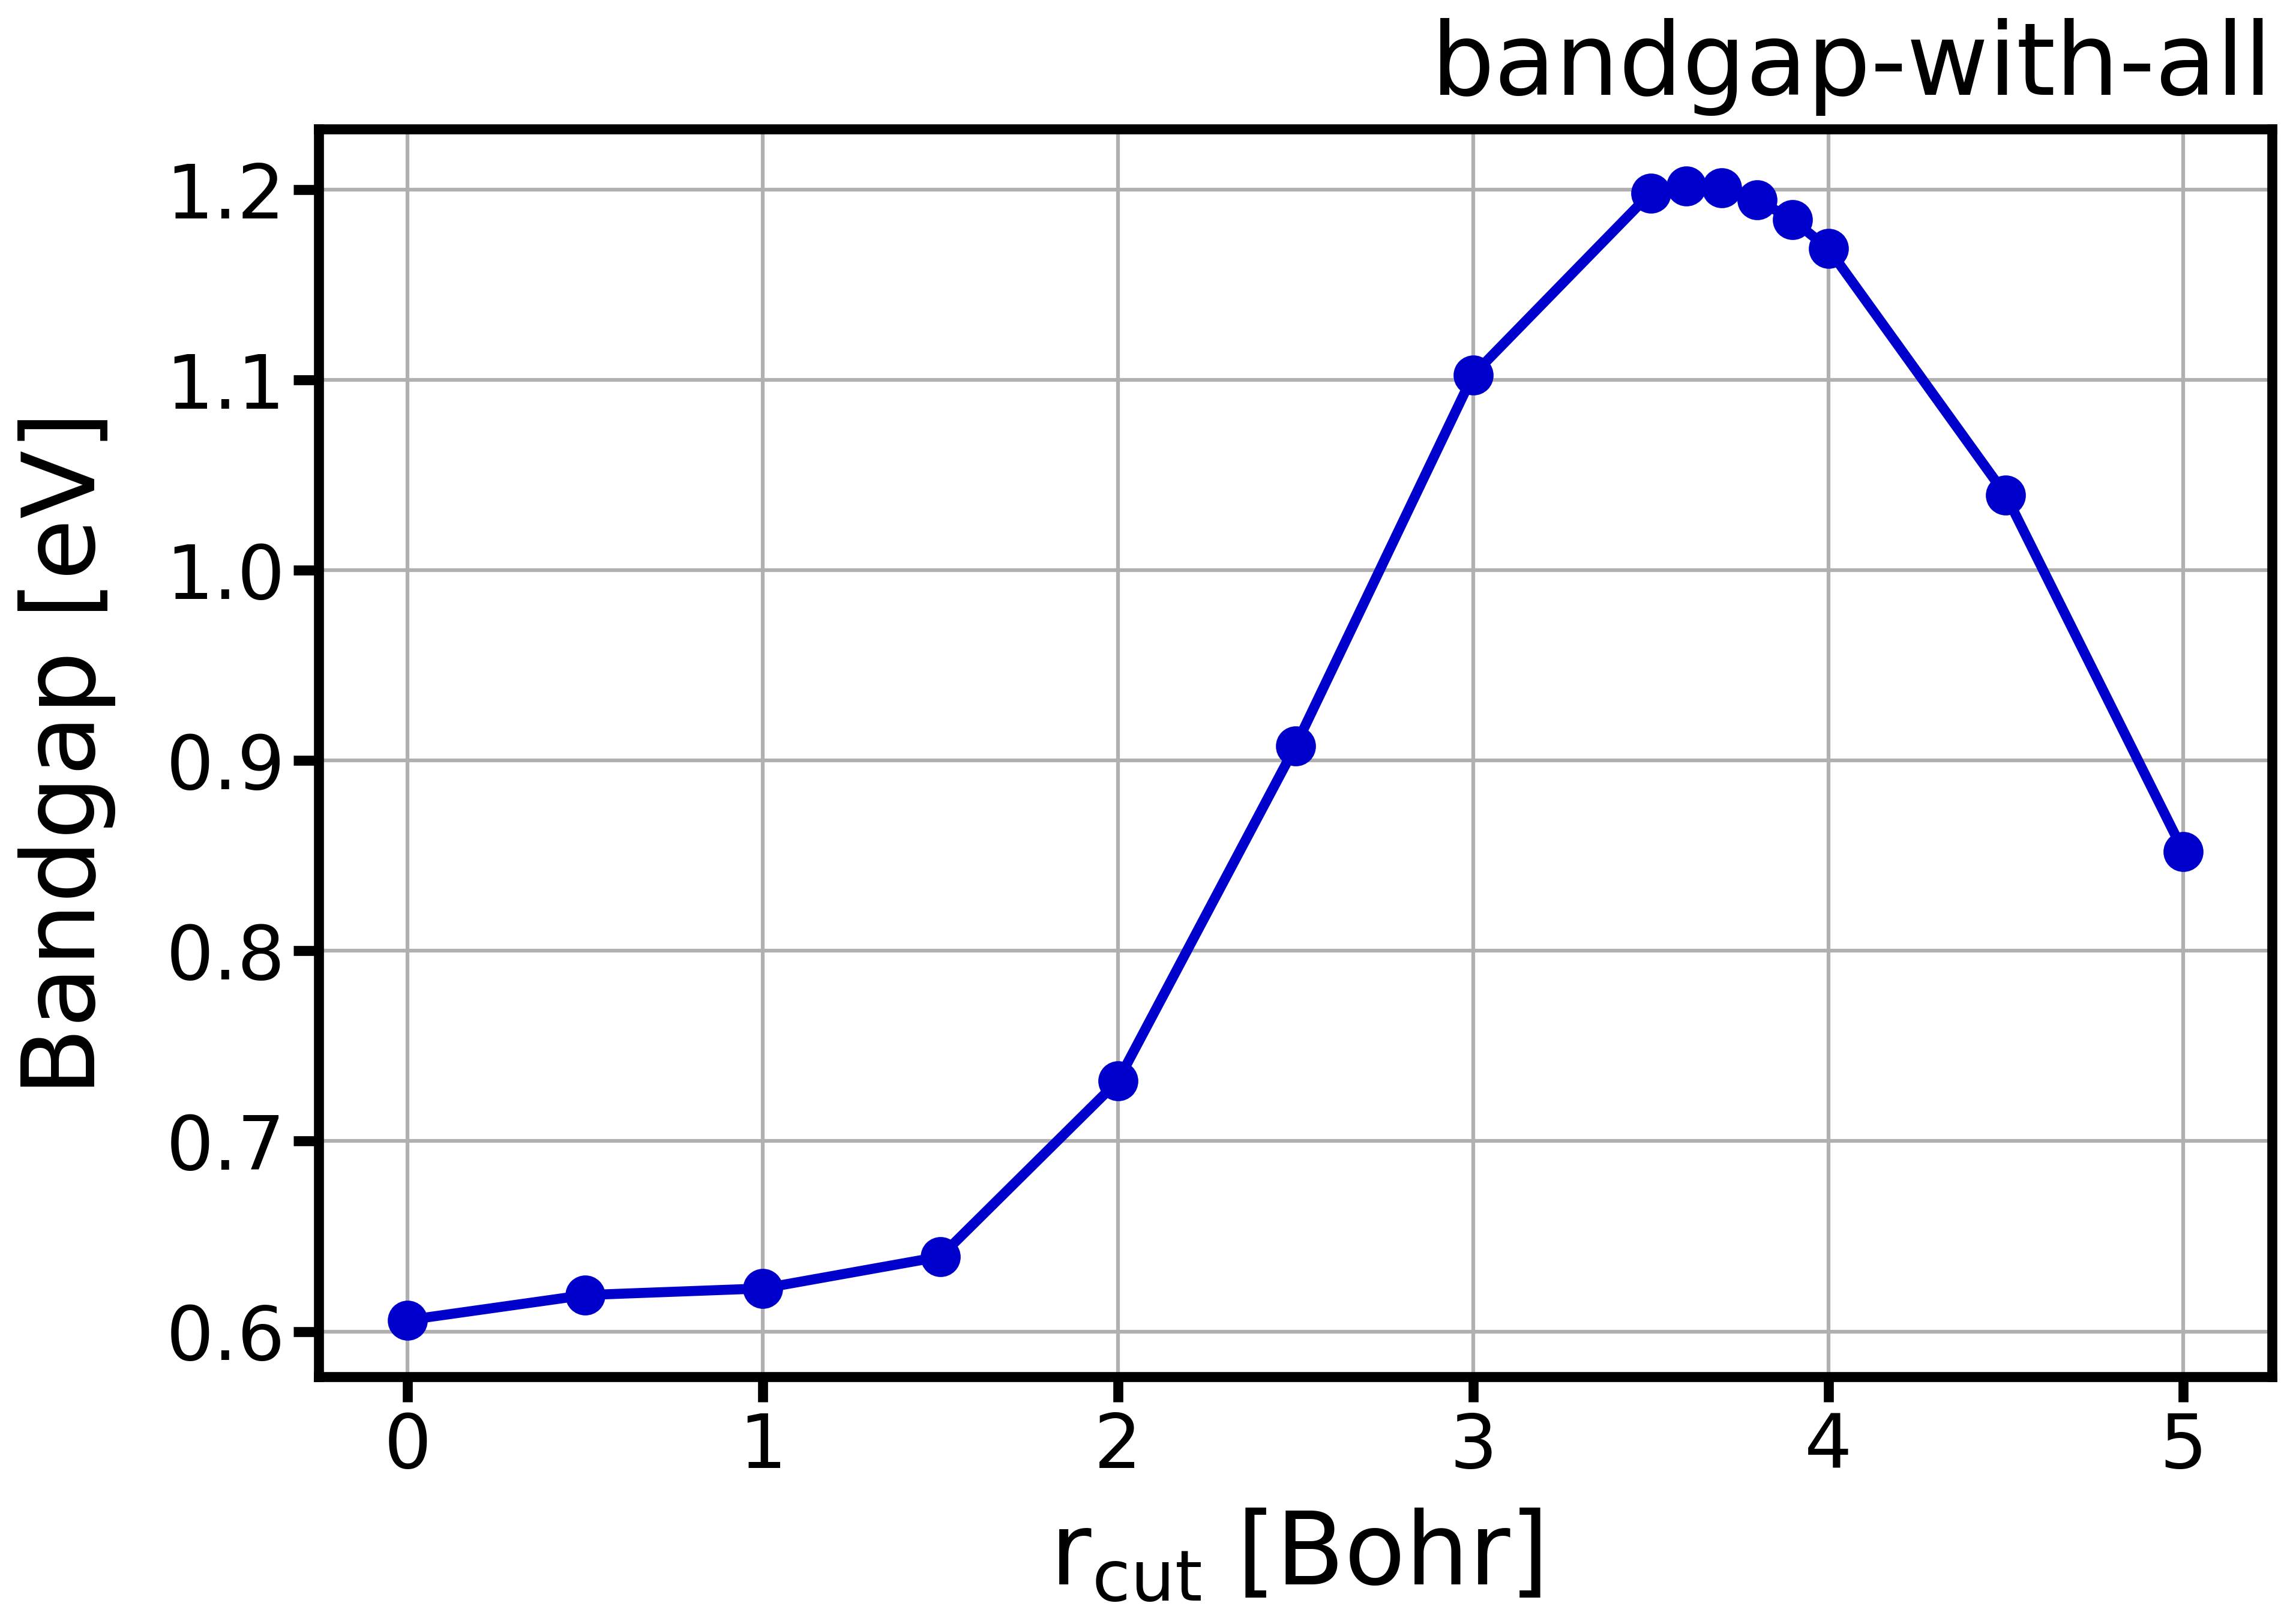
</figure>

Now, you see that the $r_{\text{cut}}$ that maximizes the band gap lies between **3.6** and **3.7** Bohr (if you want, you can refine it further), and the band gap obtained with **LDA-1/2** is **1.20** eV. Note that, for a more precise result, you should have changed since the beginning to a better <code><span style="color:mediumblue">ngridk</span></code> (for Si, this **does** matter, because it has an indirect band gap).

<a id='3.2'></a>
#### <span style="color:#15317E">3.2 Bulk GaN</span>
Once you have applied the **LDA-1/2** method to bulk Si, you can try now to apply the method to GaN. The ground-state structure of this material is the hexagonal wurtzite. However, we will employ here the zinc-blende phase, because it is easier and faster to be calculated. Go back to the previous directory where you were saving the calculations done in this tutorial, create a new folder and enter inside it.

In [ ]:
%%bash -l
cd run_tutorial_LDA_0.5
mkdir -p cut-GaN
cd ..

The procedure to apply the **LDA-1/2** to GaN is similar to that one you learned for Si, but now, in principle, you should care about "*ionizing*" Ga and N. As the orbitals of N are the ones that contribute most to the top of the crytals valence band, a very good approximation is to consider only the self-energy potential for N. This is what we will do here.

To determine the $r_{\text{cut}}$ of N that maximizes the band gap, you can start by inserting the following content

<span class="GaN_LDA_1/2"></span>
```xml
<input>
 
   <title>Zinc-blende GaN: LDA-1/2 example</title>
 
   <structure speciespath="$EXCITINGROOT/species">
      <crystal scale="8.5038">
         <basevect>0.0   0.5   0.5</basevect>
         <basevect>0.5   0.0   0.5</basevect>
         <basevect>0.5   0.5   0.0</basevect>
      </crystal>
      <species speciesfile="N.xml" rmt="1.6">
         <atom coord="0.25 0.25 0.25"/>
         <dfthalfparam>
            <shell cut="2.0" ampl="1" exponent="8" number="0" ionization="0.5" />
         </dfthalfparam>
      </species>
      <species speciesfile="Ga.xml" rmt="1.6">
         <atom coord="0.00 0.00 0.00"/>
         <dfthalfparam>
            <shell cut="0.00" ampl="1" exponent="8" number="-2" ionization="0.5" />
         </dfthalfparam>
      </species>
   </structure>
 
   <groundstate
      do="fromscratch"
      rgkmax="7.0"
      gmaxvr="14"
      ngridk="6 6 6"
      outputlevel="high"
      xctype="LDA_PW">
      <dfthalf printVSfile="false"/>
   </groundstate>
 
</input>
```

into a file **input.xml** inside the current directory. Then, proceed analogously to Si, but perform the calculations for N.

We provide some data (of $r_{\text{cut}}$ and band gap) for you to check your results.
```
     3.60000000    1.2020510144
     3.70000000    1.2008270463
     3.80000000    1.1947749618
     3.90000000    1.1841189830
```

Using the script **`excitingscripts.plot.files`**, you should get something like the following.

<figure>
<img src=" 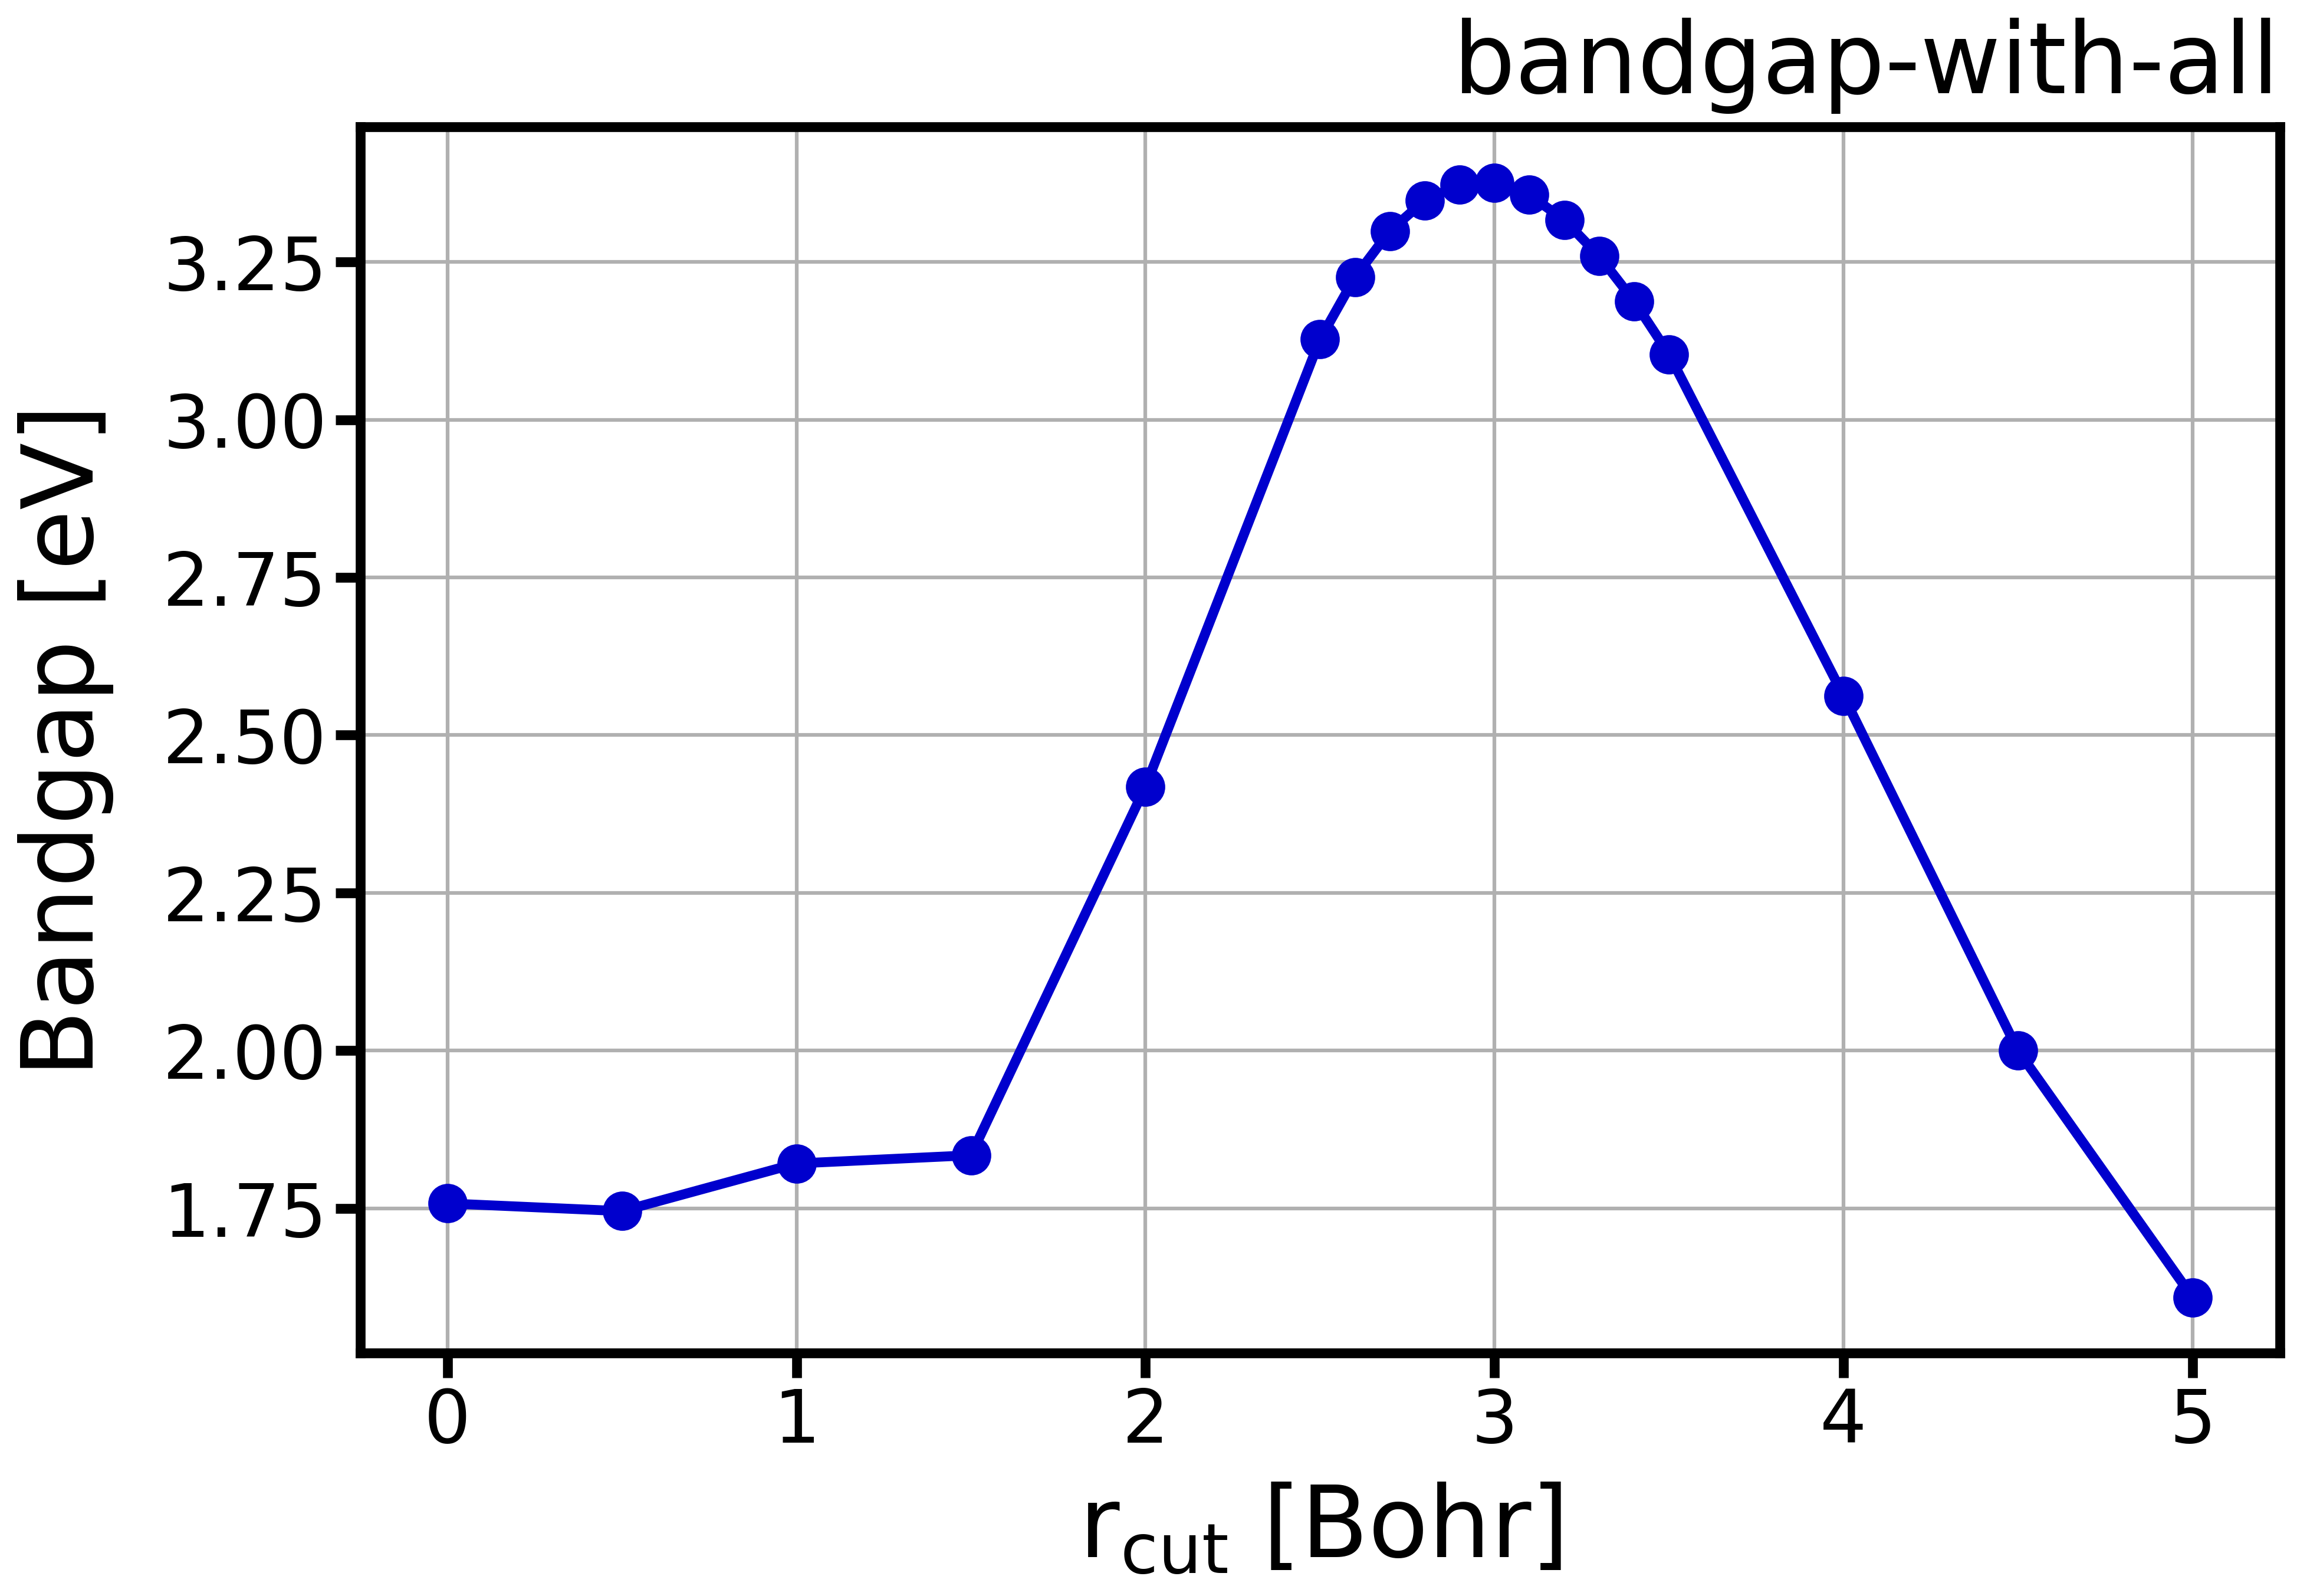" width="600" align="left"/>
</figure>

This leads you to the conclusion that the $r_{\text{cut}}$ of N (that maximizes the band gap) is **3.0** (within an accuracy of **0.1**) and, that the band gap of GaN calculated through the **LDA-1/2** method is **3.38** eV (which exhibits nice agreement with the experimental one, of **3.3** eV).

<a id='3.3'></a>
#### <span style="color:#15317E">3.3. Band Structure and DOS</span>
Of course, it is possible to plot band-structures and density of states when using **DFT-1/2**. You just need to follow the same procedure as in the tutorial **Electronic band-structure and density of states**, adding to **input.xml** the elements and attributes that are specific for DFT-1/2 calculations. You can plot these graphs for Si and GaN as an exercise.

#### <span style="color:#15317E">3.4. Transferability</span>
The value of the parameter $r_{\text{cut}}$ that maximizes the band gap should be obtained for each material to be studied with the **LDA-1/2** method. However, in many cases, you can assume that it is transferable (indeed, this has been verified in many calculations). Therefore, if you are interested in calculations of interfaces, you can determine the $r_{\text{cut,optimized}}$ separately for each material that comprises the interface, and then employ these "*optimal*" $r_{\text{cut}}$ for the interface. Another example of transferability would appear considering our example of GaN and supposing that you want to study, for example, AlN: in principle, the same $r_{\text{cut,optimized}}$ obtained for N in GaN can be applied to AlN.

<a id='4'></a>
<hr style="border:1px solid #DDD"> </hr>

### <span style="color:#15317E">Literature</span>
More details about the **DFT-1/2** formalism:
- L.G. Ferreira, M. Marques, L.K. Teles. "*Approximation to density functional theory for the calculation of band gaps of semiconductors*", Phys. Rev. B **78**, 125116 (2008);
- L.G. Ferreira, M. Marques, L.K. Teles. "*Slater half-occupation technique revisited: the LDA-1/2 and GGA-1/2 approaches for atomic ionization energies and band gaps in semiconductors*", AIP Adv. *1*, 032119 (2011).

<hr style="border:2px solid #DDD"> </hr>